# Part III: Time-Series Forecasting using RNNs [20 pts]
In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install torchinfo

In [39]:
import torch
import torch.nn as nn

import torchinfo
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns

import time

from tqdm import tqdm

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import random

In [5]:
seed = 18
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Step 1: Data exploration and preprocessing

In [7]:
dataset = pd.read_csv('/content/drive/My Drive/dataset/part3_dataset/AirQualityUCI.csv', sep=';', decimal=',')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [ ]:
dataset.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


In [ ]:
dataset.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


<span style='color:green'>The dataset contains hourly averaged measurements from five metal oxide chemical sensors embedded in an air quality multisensor device. In addition to the sensor readings, ground truth concentrations for pollutants—including CO, Non-Methane Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx), and Nitrogen Dioxide (NO2)—were obtained from a co-located reference-certified analyzer. Missing values in the dataset are marked with a value of -200.
<a href="https://archive.ics.uci.edu/dataset/360/air+quality"> Dataset Link</a></span>

2. Identify any missing values.

In [8]:
preprocessed_dataset = dataset.replace(-200, np.nan)

In [9]:
pd.isna(preprocessed_dataset).sum()

,0
Date,114
Time,114
CO(GT),1797
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


3. Handle any missing values (imputation or removal).

In [10]:
preprocessed_dataset = preprocessed_dataset.drop(['NMHC(GT)', 'Unnamed: 15', 'Unnamed: 16'], axis=1)

In [11]:
preprocessed_dataset = preprocessed_dataset.dropna(subset=['Date', 'Time'])

In [12]:
pd.isna(preprocessed_dataset).sum()

,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642
PT08.S4(NO2),366


In [13]:
preprocessed_dataset = preprocessed_dataset.sort_values(by=['Date', 'Time'])
float_cols = preprocessed_dataset.select_dtypes(include=['float64']).columns
preprocessed_dataset[float_cols] = preprocessed_dataset[float_cols].interpolate(method='linear', limit_direction='both', axis=0)

In [14]:
pd.isna(preprocessed_dataset).sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0


4. Create at least three different visualizations to explore the dataset.

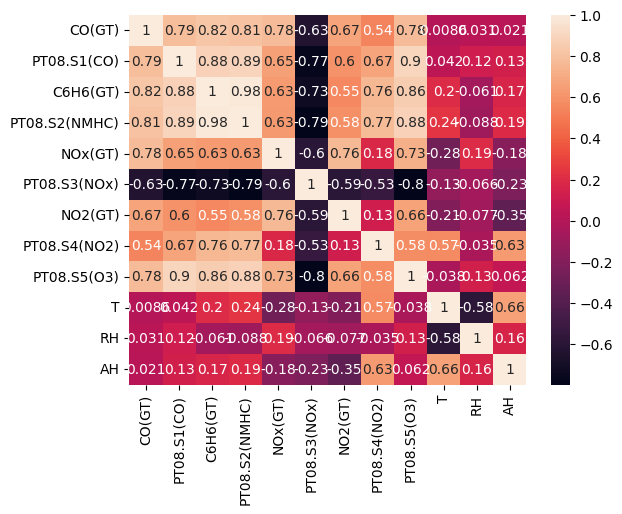

In [ ]:
sns.heatmap(preprocessed_dataset.corr(numeric_only=True), annot=True)
plt.show()

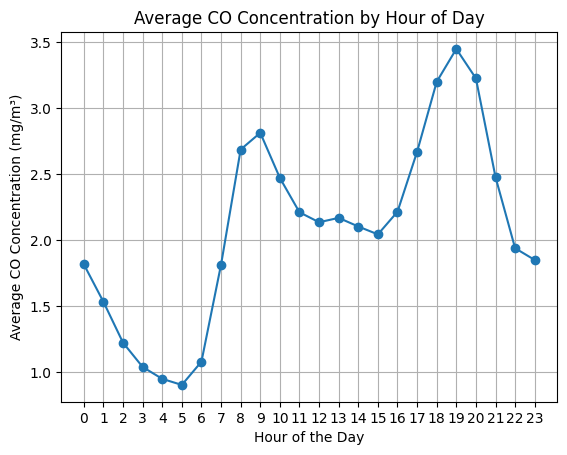

In [ ]:
preprocessed_dataset['Datetime'] = pd.to_datetime(preprocessed_dataset['Date'] + ' ' + preprocessed_dataset['Time'], format='%d/%m/%Y %H.%M.%S')
preprocessed_dataset['Hour'] = preprocessed_dataset['Datetime'].dt.hour
hourly_mean = preprocessed_dataset.groupby('Hour')['CO(GT)'].mean()

plt.plot(hourly_mean.index, hourly_mean.values, marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average CO Concentration (mg/m³)')
plt.title('Average CO Concentration by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

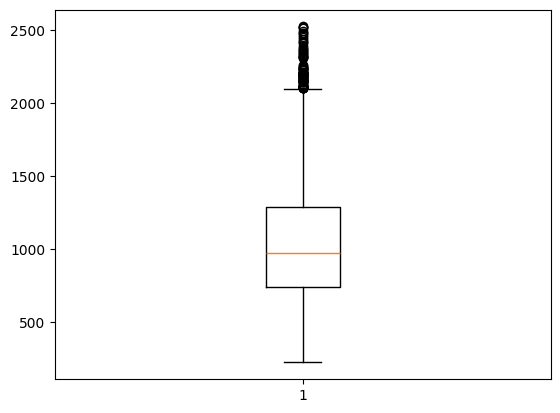

In [ ]:
plt.boxplot(preprocessed_dataset['PT08.S5(O3)'])
plt.show()

<span style='color:green'>
<ul>
<li> Many features exhibit high correlations, while Pt08.S3 shows the lowest correlation with other variables, as indicated by its darker color shading.</li>
<li>The plot illustrates how CO levels fluctuate throughout the day, peaking at night and reaching their lowest point at dawn.</li>
<li>This boxplot reveals a skewed distribution with several extreme high values that significantly deviate from the bulk of the data.</li>
</ul>
</span>

5. Normalize or standardize your data using appropriate techniques.

In [ ]:
preprocessed_dataset.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,2.085556,1101.222668,10.096265,940.022657,231.404457,833.347761,108.589772,1451.344395,1029.568719,18.164492,49.337443,1.018857,2004-09-21 16:00:00
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,939.000000,4.500000,740.000000,99.000000,660.000000,74.000000,1224.000000,739.000000,11.500000,36.200000,0.734400,2004-06-16 05:00:00
50%,1.762500,1067.000000,8.300000,910.000000,167.000000,804.000000,103.000000,1455.800000,972.000000,17.600000,49.700000,0.986500,2004-09-21 16:00:00
75%,2.700000,1231.000000,13.900000,1112.190476,299.000000,964.000000,135.000000,1664.000000,1283.200000,24.300000,62.600000,1.300500,2004-12-28 03:00:00
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.381372,215.239302,7.388981,264.191904,200.255641,253.611374,46.488753,343.237690,396.688166,8.809310,17.179191,0.400759,NaN


6. Split the data into training, validation, and testing sets.

In [17]:
train_size = int(len(preprocessed_dataset) * 0.7)
val_size = int(len(preprocessed_dataset) * 0.15)
train_data = preprocessed_dataset[:train_size]
val_data = preprocessed_dataset[train_size:train_size + val_size]
test_data = preprocessed_dataset[train_size + val_size:]

In [18]:
scaler = StandardScaler()
float_cols = train_data.select_dtypes(include=['float']).columns
train_data[float_cols] = scaler.fit_transform(train_data[float_cols])
val_data[float_cols] = scaler.transform(val_data[float_cols])
test_data[float_cols] = scaler.transform(test_data[float_cols])

<ipython-input-18-4a8a8a58b9b6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[float_cols] = scaler.fit_transform(train_data[float_cols])
<ipython-input-18-4a8a8a58b9b6>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_data[float_cols] = scaler.transform(val_data[float_cols])
<ipython-input-18-4a8a8a58b9b6>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

7. Sequence Creation

In [19]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [20]:
seq_length = 20
x_train, y_train = create_sequences(train_data["CO(GT)"].values, seq_length)
x_val, y_val = create_sequences(val_data['CO(GT)'].values, seq_length)
x_test, y_test = create_sequences(test_data['CO(GT)'].values, seq_length)

In [21]:
class timeseries(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.len = x.shape[0]

    def __getitem__(self,idx):
        return self.x[idx].unsqueeze(-1), self.y[idx]

    def __len__(self):
        return self.len

In [22]:
train_dataset = timeseries(x_train, y_train)
val_dataset = timeseries(x_val, y_val)
test_dataset = timeseries(x_test, y_test)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
val_loader = DataLoader(val_dataset, shuffle=False, batch_size=32)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=32)

## Step 2: Model development

In [23]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, bidirectional=False, dropout=0.2):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_direction = 2 if bidirectional else 1
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.fc1 = nn.Linear(hidden_size * self.num_direction, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None, c0=None):
        lstm_out, _ = self.lstm(x)

        last_out = lstm_out[:, -1, :]

        x = self.fc1(last_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [ ]:
lstm = LSTM(input_size=1, hidden_size=64, num_layers=3,output_size=1)

In [ ]:
torchinfo.summary(lstm, input_size=(32, seq_length, 1))

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [32, 1]                   --
├─LSTM: 1-1                              [32, 20, 64]              83,712
├─Linear: 1-2                            [32, 64]                  4,160
├─ReLU: 1-3                              [32, 64]                  --
├─Dropout: 1-4                           [32, 64]                  --
├─Linear: 1-5                            [32, 1]                   65
Total params: 87,937
Trainable params: 87,937
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 53.71
Input size (MB): 0.00
Forward/backward pass size (MB): 0.34
Params size (MB): 0.35
Estimated Total Size (MB): 0.70

In [24]:
def train_one_epoch(model , train_loader  , optimizer , loss_function   ):
    model.train()

    epoch_loss = 0.0
    correct_pred = 0
    total_pred = 0


    for i , (sequences , labels) in tqdm(enumerate(train_loader)):
        sequences, labels = sequences.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = loss_function(outputs.squeeze(), labels)

        loss.backward()
        optimizer.step()


        epoch_loss += loss.item()
        _,pred = torch.max(outputs , 1)

    optimizer.step()
    optimizer.zero_grad()

    avg_train_loss = epoch_loss/len(train_loader)

    print(f"Training loss {avg_train_loss} ")

    return avg_train_loss

In [26]:
def val(model , loader , loss_function ):
    model.eval()

    curr_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for sequences, labels in tqdm(loader):
            sequences, labels = sequences.to(device), labels.to(device)

            output = model(sequences)
            batch_loss = loss_function(output.squeeze(), labels)

            curr_loss += batch_loss.item()

    epoch_loss = curr_loss/len(loader)

    print(f"validation loss { epoch_loss}")

    return epoch_loss

In [27]:
def train(model , train_loader , val_loader , epochs , optimizer , loss_function , training_details , best_model_path=None, scheduler=None):
    train_loss_list = []
    val_loss_list = []
    lr_reduction = 0

    best_val_loss = float('inf')

    start_time = time.time()

    for epoch in range(epochs):
        print("\n\n\n********************************************")
        print(f"Epoch :{epoch + 1}")
        print(f"Learning Rate {optimizer.param_groups[0]['lr']}")
        train_loss = train_one_epoch(
                                        model=model,
                                        train_loader=train_loader,
                                        optimizer=optimizer,
                                        loss_function=loss_function,
                                        )


        val_loss = val(
                                model=model,
                                loader=val_loader,
                                loss_function=loss_function
                            )
        # if scheduler is not None:
        #     prev_lr = optimizer.param_groups[0]['lr']
        #     scheduler.step(val_acc)
        #     current_lr = optimizer.param_groups[0]['lr']
        #     if current_lr < prev_lr:
        #         lr_reduction += 1

        if best_model_path is not None and val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved at epoch {epoch+1} with validation loss {val_loss:.4f}")

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

    end_time = time.time()

    print(f"\nExecution Time: {(end_time-start_time):.6f} seconds")

    training_details["train_loss"].extend(train_loss_list)
    training_details["val_loss"].extend(val_loss_list)

In [28]:
def evaluate(model , test_loader , loss_function ):
    y_true = []
    y_pred = []

    curr_loss = 0

    with torch.no_grad():
        for sequences, labels in tqdm(test_loader, desc="Testing", leave=False):
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            batch_loss = loss_function(outputs.squeeze() , labels)
            curr_loss += batch_loss.item()
            y_pred.extend(list(outputs.cpu().numpy()))
            y_true.extend(list(labels.cpu().numpy()))

        epoch_loss = curr_loss/len(test_loader)

        print(f"Loss : {epoch_loss}")

    return {"y_true": y_true , "y_pred": y_pred , "epoch_loss": epoch_loss}

In [ ]:
# Experiment with different architectures (bidirectional)
# 1. bidirectional = False
lstm = LSTM(input_size=1, hidden_size=64, num_layers=3,output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm.parameters(), lr=0.001)
best_model_path = "/content/drive/My Drive/weights/lstm.pt"
training_details = {
    "train_loss": [],
    "val_loss": []
}

train(
    model=lstm,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=best_model_path
    )




********************************************
Epoch :1
Learning Rate 0.001


202it [00:09, 38.01it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
205it [00:09, 22.62it/s]


Training loss 0.5157386998941259 


100%|██████████| 44/44 [00:00<00:00, 118.44it/s]


validation loss 0.3879542980470102
New best model saved at epoch 1 with validation loss 0.3880



********************************************
Epoch :2
Learning Rate 0.001


...

validation loss 0.2544065115296028



********************************************
Epoch :15
Learning Rate 0.001


205it [00:03, 68.29it/s]


Training loss 0.20020102905052736 


100%|██████████| 44/44 [00:00<00:00, 169.56it/s]

validation loss 0.282061954960227

Execution Time: 82.531160 seconds


In [ ]:
lstm.load_state_dict(torch.load(best_model_path))
test_result_lstm  = evaluate(lstm , test_loader , criterion)

<ipython-input-229-d34f808c87cc>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm.load_state_dict(torch.load(best_model_path))
                                         

Loss : 0.16065029180423485


In [ ]:
# 2. bidirectional = True
lstm_bidirectional = LSTM(input_size=1, hidden_size=64, num_layers=3,output_size=1, bidirectional=True)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_bidirectional.parameters(), lr=0.001)
best_model_path = "/content/drive/My Drive/weights/lstm_bidirectional.pt"
training_details = {
    "train_loss": [],
    "val_loss": []
}

train(
    model=lstm_bidirectional,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=best_model_path
    )




********************************************
Epoch :1
Learning Rate 0.001


203it [00:11, 18.47it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
205it [00:11, 17.71it/s]


Training loss 0.4283776753559345 


100%|██████████| 44/44 [00:00<00:00, 54.04it/s]


validation loss 0.3250044686719775
New best model saved at epoch 1 with validation loss 0.3250



********************************************
Epoch :2
Learning Rate 0.001


...

validation loss 0.24590735518458215



********************************************
Epoch :15
Learning Rate 0.001


205it [00:08, 25.35it/s]


Training loss 0.20761330005962675 


100%|██████████| 44/44 [00:00<00:00, 79.68it/s]

validation loss 0.2481302134692669

Execution Time: 133.355481 seconds


In [ ]:
lstm_bidirectional.load_state_dict(torch.load(best_model_path))
test_result_lstm_bd  = evaluate(lstm_bidirectional , test_loader , criterion)

<ipython-input-228-15dc17b44bd4>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_bidirectional.load_state_dict(torch.load(best_model_path))
                           

Loss : 0.16428066563358615


In [ ]:
# Experiment with different Droup value
#1. 0.2
#2. 0.5
lstm_dropout5 = LSTM(input_size=1, hidden_size=64, num_layers=3, output_size=1, dropout=0.5)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_dropout5.parameters(), lr=0.001)
best_model_path = "/content/drive/My Drive/weights/lstm_droupout5.pt"
training_details = {
    "train_loss": [],
    "val_loss": []
}

train(
    model=lstm_dropout5,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=best_model_path
    )




********************************************
Epoch :1
Learning Rate 0.001


201it [00:04, 45.04it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
205it [00:04, 41.73it/s]


Training loss 0.5655389833014186 


100%|██████████| 44/44 [00:00<00:00, 120.13it/s]


validation loss 0.42712950791147625
New best model saved at epoch 1 with validation loss 0.4271



********************************************
Epoch :2
Learning Rate 0.001


...

validation loss 0.23506164258684625
New best model saved at epoch 14 with validation loss 0.2351



********************************************
Epoch :15
Learning Rate 0.001


205it [00:05, 34.28it/s]


Training loss 0.21702460868329537 


100%|██████████| 44/44 [00:00<00:00, 116.64it/s]

validation loss 0.2683532349765301

Execution Time: 95.121045 seconds


In [ ]:
lstm_dropout5.load_state_dict(torch.load(best_model_path))
test_result_lstm_dropout5  = evaluate(lstm_dropout5 , test_loader , criterion)

<ipython-input-227-d91a1c925c95>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_dropout5.load_state_dict(torch.load(best_model_path))
                                

Loss : 0.1619312308136035


In [ ]:
# Tune hyperparameters: learing rate
#1. 0.001
#2. 0.0001
lstm_lr3 = LSTM(input_size=1, hidden_size=64, num_layers=3, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_lr3.parameters(), lr=0.0001)
best_model_path = "/content/drive/My Drive/weights/lstm_lr3.pt"
training_details = {
    "train_loss": [],
    "val_loss": []
}

train(
    model=lstm_lr3,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=best_model_path
    )




********************************************
Epoch :1
Learning Rate 0.0001


205it [00:08, 23.25it/s]


Training loss 0.9757221867398518 


100%|██████████| 44/44 [00:00<00:00, 67.87it/s]


validation loss 1.2441295808689161
New best model saved at epoch 1 with validation loss 1.2441



********************************************
Epoch :2
Learning Rate 0.0001


...

validation loss 0.3079858816821467



********************************************
Epoch :15
Learning Rate 0.0001


205it [00:02, 69.77it/s]


Training loss 0.23362842501118417 


100%|██████████| 44/44 [00:00<00:00, 161.71it/s]

validation loss 0.300259655341506
New best model saved at epoch 15 with validation loss 0.3003

Execution Time: 70.272209 seconds


In [ ]:
lstm_lr3.load_state_dict(torch.load(best_model_path))
test_result_lstm_lr3  = evaluate(lstm_lr3 , test_loader , criterion)

<ipython-input-231-627e14b4a190>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_lr3.load_state_dict(torch.load(best_model_path))
                                     

Loss : 0.1761650083472804


In [ ]:
# Tune hyperparameters: epochs
#1. 15
#2. 50
lstm_ep50 = LSTM(input_size=1, hidden_size=64, num_layers=3, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_ep50.parameters(), lr=0.0001)
best_model_path = "/content/drive/My Drive/weights/lstm_ep50.pt"
training_details = {
    "train_loss": [],
    "val_loss": []
}

train(
    model=lstm_ep50,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=best_model_path
    )




********************************************
Epoch :1
Learning Rate 0.0001


201it [00:04, 41.88it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
205it [00:04, 45.20it/s]


Training loss 0.967077961927507 


100%|██████████| 44/44 [00:00<00:00, 107.92it/s]


validation loss 1.2438900010152296
New best model saved at epoch 1 with validation loss 1.2439



********************************************
Epoch :2
Learning Rate 0.0001


...

validation loss 0.2317097590897571
New best model saved at epoch 49 with validation loss 0.2317



********************************************
Epoch :50
Learning Rate 0.0001


205it [00:04, 48.63it/s]


Training loss 0.19664355830811872 


100%|██████████| 44/44 [00:00<00:00, 160.70it/s]

validation loss 0.25069861888716166

Execution Time: 192.160042 seconds


In [ ]:
lstm_ep50.load_state_dict(torch.load(best_model_path))
test_result_lstm_ep50  = evaluate(lstm_ep50 , test_loader , criterion)

<ipython-input-233-656243655671>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_ep50.load_state_dict(torch.load(best_model_path))
                                    

Loss : 0.15264515116789631


In [29]:
# 3. 100
lstm_ep100 = LSTM(input_size=1, hidden_size=64, num_layers=3, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_ep100.parameters(), lr=0.0001)
best_model_path = "/content/drive/My Drive/weights/lstm_ep100.pt"
training_details = {
    "train_acc": [],
    "val_acc": [],
    "train_loss": [],
    "val_loss": []
}

train(
    model=lstm_ep100,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=best_model_path
    )




********************************************
Epoch :1
Learning Rate 0.0001


203it [00:13, 23.35it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
205it [00:13, 15.55it/s]


Training loss 0.9724671881009893 


100%|██████████| 44/44 [00:00<00:00, 83.31it/s]


validation loss 1.247301701794971
New best model saved at epoch 1 with validation loss 1.2473



********************************************
Epoch :2
Learning Rate 0.0001


...

validation loss 0.25211961060466076



********************************************
Epoch :100
Learning Rate 0.0001


205it [00:05, 36.86it/s]


Training loss 0.17409666922034286 


100%|██████████| 44/44 [00:00<00:00, 128.62it/s]

validation loss 0.24331388912502339

Execution Time: 711.440999 seconds


3. Save the weights of the trained neural network that provides the best results.

In [31]:
# not bidirectional
# Droup 0.2
# learning rate 0.0001
# num of epochs 100

lstm_ep100.load_state_dict(torch.load(best_model_path))
test_result_lstm_ep100  = evaluate(lstm_ep100 , test_loader , criterion)

<ipython-input-31-3ee4fce3f1bd>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_ep100.load_state_dict(torch.load(best_model_path))
                                    

Loss : 0.1508405133499764


## Step 3: Evaluation and analysis

In [33]:
def plot_extended(type, list_dic):
    colors = colormaps.get_cmap('tab20')
    epochs = max(len(list) for list in list_dic.values())
    plt.figure(figsize=(20, 6))
    for i, (model, loss) in enumerate(list_dic.items()):
        if(len(loss) < epochs):
            loss_extended = loss+[loss[-1] for _ in range(epochs-len(loss))]
            plt.plot(range(1, len(loss)+1), loss, label=f"{model} {type}", marker='o', color = colors(i))
            plt.plot(range(len(loss), epochs+1), loss_extended[len(loss)-1:], '--', label=f"{model} {type} (extended)", color = colors(i))
        else:
            plt.plot(range(1, epochs+1), loss, label=f"{model} {type}", marker='o', color = colors(i))

    plt.title(f'{list(list_dic.keys())} {type}')
    plt.xlabel('Epochs')
    plt.ylabel(f"{type}")
    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()

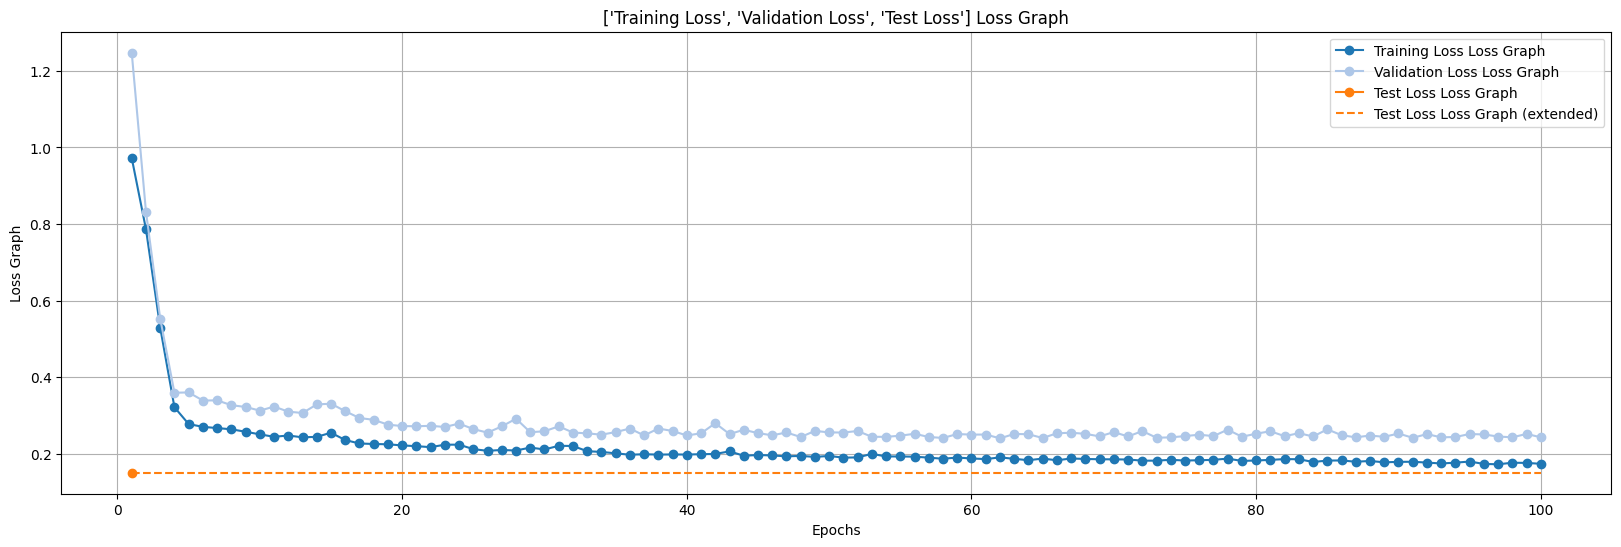

In [35]:
loss_lists = {"Training Loss": training_details['train_loss'], "Validation Loss": training_details['val_loss'], "Test Loss": [test_result_lstm_ep100['epoch_loss']]}
plot_extended(type="Loss Graph", list_dic = loss_lists)

In [40]:
y_pred = test_result_lstm_ep100['y_pred']
y_true = test_result_lstm_ep100['y_true']
mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)
rmse = root_mean_squared_error(y_true=y_true, y_pred=y_pred)
r2 = r2_score(y_true=y_true, y_pred=y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.24816930863807912
RMSE: 0.39157274150099897
R-squared: 0.8043645567957445


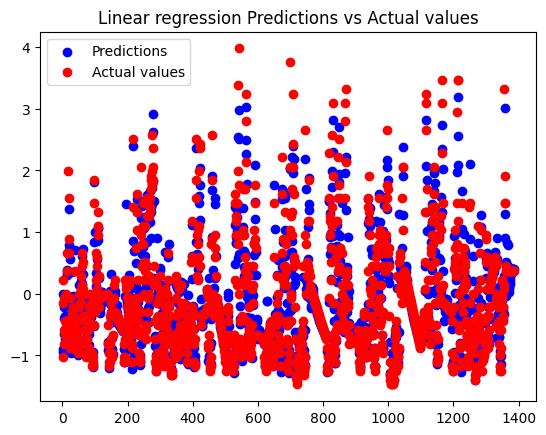

In [41]:
n = y_test.shape[0]
plt.scatter([x for x in range(1, n+1)], y_pred, color='blue', label='Predictions')
plt.scatter([x for x in range(1, n+1)], y_test, color='red', label='Actual values')

plt.title('Predictions vs Actual values')
plt.legend()
plt.show()

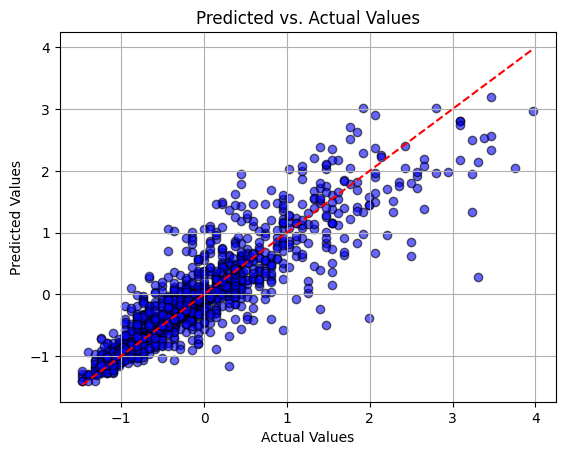

In [45]:
plt.scatter(y_true, y_pred, alpha=0.6, color='blue', edgecolors='k')
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual Values")
plt.grid(True)
plt.show()

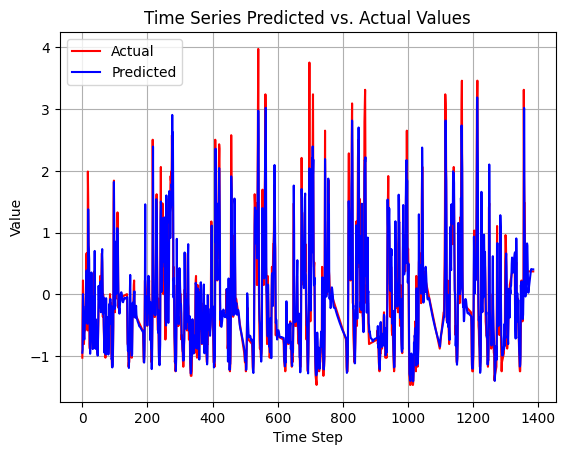

In [47]:
plt.plot(y_true, label='Actual', color='red')
plt.plot(y_pred, label='Predicted', color='blue')
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title("Time Series Predicted vs. Actual Values")
plt.legend()
plt.grid(True)
plt.show()

<span style='color:green'>
<ul>
<li>The air quality dataset consists of hourly averaged measurements from an array of five metal oxide chemical sensors embedded in an air quality multisensor device. Missing values are indicated by -200, and some features have over 1,600 missing entries; these were imputed using the mean of nearby data points. I used the dataset to predict CO value.</li>

<li>My final LSTM architecture comprises three stacked LSTM layers followed by a fully connected layer. A dropout rate of 0.2 is applied between layers to help mitigate overfitting. I set the sequence length to 20 hours to capture daily patterns in the air quality measurements.</li>

<li>The model achieved solid performance, with an MAE of 0.248 and an RMSE of 0.392, yielding an R-squared of approximately 0.80. As shown in the scatter plot, the predictions generally align well with the actual values, clustering around the diagonal. The time-series line plot suggests the model captures overall trends and daily fluctuations, although it occasionally under- or overestimates rapid spikes.

Hyperparameter tuning, particularly for learning rate, number of epochs, and dropout rate, played a key role in improving these results. Using smaller learning rate and larger number of epochs allowed the model to learn daily patterns better. Increasing dropout from lower values to 0.2 also helped regularize the network, reducing validation loss.</li>

<li>While the model tracks the main trends, there are still moments where sudden peaks or dips are missed. This indicates that further refinement—such as or experimenting with deeper architectures—may help the model capture these abrupt changes more effectively.
And I think more sophisticated hyperparameter tuning will improve the performance. </li>
</ul>
</span>

5. References.

<span style='color:green'>
<ul>
<li>Part 3, Step 1,2,3 are based on Deep Learning Assignment 2 by Heeju Hwang and Shubham Shubham</li>
<li>Part 3, Step 3 is based on Fall 2024 Machine Learning Assignment 1 by Heeju Hwang</li>
<li>https://archive.ics.uci.edu/dataset/360/air+quality</li>
<li>https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html</li>
<li>https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html</li>
<li>https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html</li>
<li>https://www.geeksforgeeks.org/long-short-term-memory-networks-using-pytorch/</li>
<li>https://www.kaggle.com/code/khalildmk/simple-two-layer-bidirectional-lstm-with-pytorch</li>
<li>https://medium.com/analytics-vidhya/pytorch-for-deep-learning-lstm-for-sequence-data-d0708fdf5717</li>
<li>https://www.scaler.com/topics/pytorch/lstm-pytorch/</li>
<li>https://scikit-learn.org/stable/modules/model_evaluation.html</li>
</ul>
</span>